In [15]:
from fredapi import Fred
import yfinance as yf
from fred_api_key import API_KEY
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

[*********************100%***********************]  1 of 1 completed


,Adj Close,Close,High,Low,Open,Volume,Asset_Returns,Risk_Free,TIPS,Expected_Inflation,Inflation,Strategy,Strategy_Returns
2003-01-02,59.820503,91.070000,91.300003,88.540001,88.849998,44516300.0,1.072717,4.07,2.43,1.64,2.75746,1,1.058079
2003-01-03,60.004440,91.349998,91.379997,90.500000,90.910004,32222600.0,1.079090,4.05,2.43,1.62,2.75746,1,1.064407
2003-01-06,61.062016,92.959999,93.489998,91.169998,91.239998,40984500.0,1.115733,4.09,2.46,1.63,2.75746,1,1.100791
2003-01-07,60.910934,92.730003,93.370003,92.199997,92.900002,38640400.0,1.110498,4.04,2.42,1.62,2.75746,1,1.095593
2003-01-08,60.030716,91.389999,92.400002,91.050003,92.199997,38702200.0,1.080000,4.00,2.29,1.71,2.75746,1,1.065311
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-13,672.039978,672.039978,680.859985,670.520020,680.500000,103457800.0,14.295362,4.11,1.83,2.28,3.02270,1,-0.577322
2025-11-14,671.929993,671.929993,675.659973,663.270020,665.380005,96846700.0,14.292859,4.14,1.86,2.28,3.02270,1,-0.577391
2025-11-17,665.669983,665.669983,673.710022,662.169983,669.700012,90456100.0,14.150384,4.13,1.85,2.28,3.02270,1,-0.581329
2025-11-18,660.080017,660.080017,665.119995,655.859985,662.099976,114467500.0,14.023158,4.12,1.85,2.27,3.02270,1,-0.584844


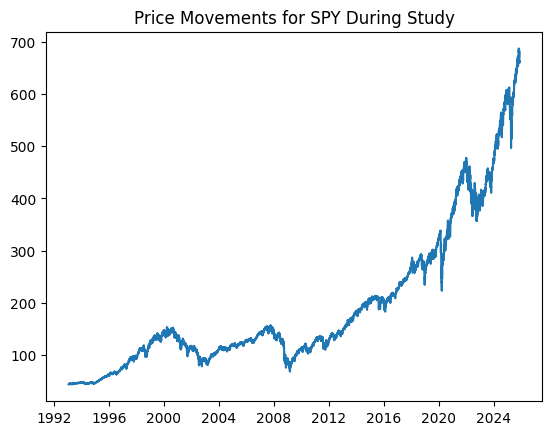

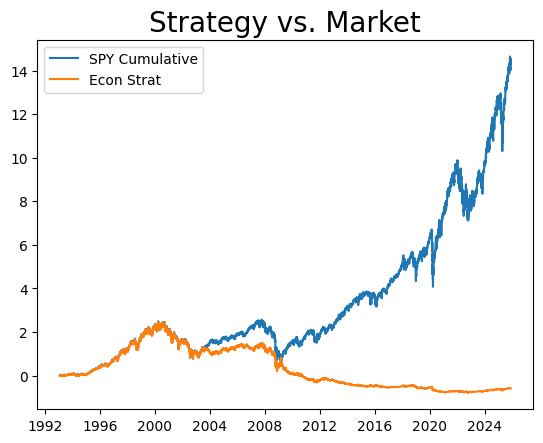

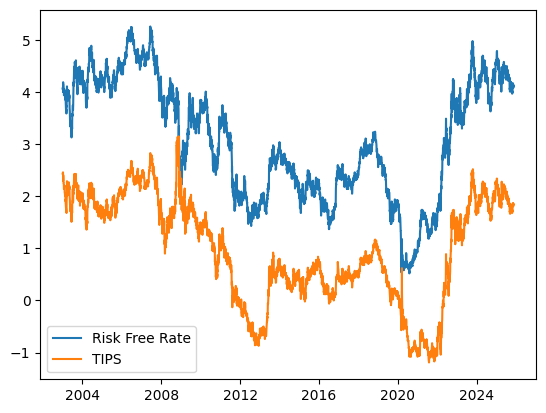

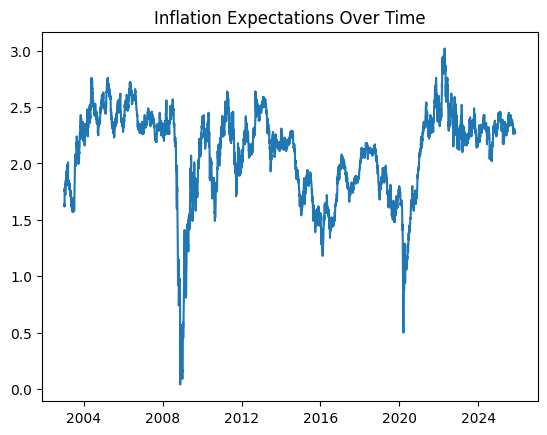

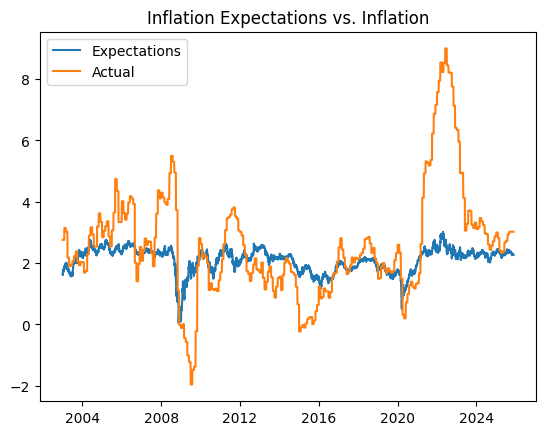

In [ ]:
TICKER = 'SPY'
INTERVAL = '1d'
PERIOD = '730d' if INTERVAL == '1h' else 'max'

LOOKBACK = 10000
fred = Fred(api_key=API_KEY)

def get_data(ticker=TICKER, lookback=LOOKBACK, interval=INTERVAL):
    df = yf.download(ticker, interval=interval, auto_adjust=False, period=PERIOD, group_by='column')
    df.columns = df.columns.get_level_values(0)

    df['Asset_Returns'] = (1 + df['Close'].pct_change()).cumprod() - 1

    # only return the subset of data you are interested in
    subset = df.iloc[-lookback:, :]
    plt.figure()
    plt.plot(subset['Close'])
    plt.title(f'Price Movements for {ticker} During Study')

    return subset.dropna()

def add_risk_free_rate(df):
    fedfunds = pd.DataFrame(fred.get_series('DGS10'), columns=['Risk_Free'])
    combined = pd.concat([df, fedfunds], axis=1) 
    return combined

def add_tips(df):
    inflation = pd.DataFrame(fred.get_series('DFII10'), columns=['TIPS'])
    combined = pd.concat([df, inflation], axis=1).ffill() 
    return combined

def add_inflation_expectations(df):
    df['Expected_Inflation'] = df['Risk_Free'] - df['TIPS']
    return df

def add_inflation(df):
    inflation = pd.DataFrame(fred.get_series('CPIAUCSL', units='pc1'), columns=['Inflation'])
    combined = pd.concat([df, inflation], axis=1).ffill() 
    return combined

def add_strategy(df):
    df['Strategy'] = np.where(df['Expected_Inflation'] > df['Inflation'], -1, 1)
    return df

def test_strategy(df):

    df['Strategy_Returns'] = (1 + df['Close'].pct_change() * df['Strategy']).cumprod() -1

    plt.figure()
    plt.plot(df['Asset_Returns'])
    plt.plot(df['Strategy_Returns'])
    plt.legend([f'{TICKER} Cumulative', 'Econ Strat'])
    plt.title('Strategy vs. Market', size='20')

    return df

def main():
    df = get_data()
    df = add_risk_free_rate(df)
    df = add_tips(df)
    df = add_inflation_expectations(df)
    df = add_inflation(df)

    df = add_strategy(df)
    df = test_strategy(df)

    df = df.dropna()


    plt.figure()
    plt.plot(df['Risk_Free'])
    plt.plot(df['TIPS'])
    plt.legend(["Risk Free Rate", "TIPS"])

    plt.figure()
    plt.plot(df['Expected_Inflation'])
    plt.title('Inflation Expectations Over Time')

    plt.figure()
    plt.plot(df['Expected_Inflation'])
    plt.plot(df['Inflation'])
    plt.title('Inflation Expectations vs. Inflation')
    plt.legend(['Expectations', 'Actual'])
    return df

main()